# Day 8 - End to End Project

## Project: California Housing Price Prediction

### Objective
- Build an end-to-end machine learning pipeline for the California Housing dataset.
- Predict median house values using a regression model.
- Evaluate model performance with RMSE, MAE, and R².

### Scope
- Data loading and exploration
- Data preprocessing and feature engineering
- Train/test split and stratified sampling
- Model training and evaluation
- Prediction checks and insights

## 1. Load dataset
Use scikit-learn's California Housing dataset.

In [16]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

print("Training set:", train_set.shape)
print("Test set:", test_set.shape)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. Explore the data
Check column names, basic statistics, and missing values.

In [17]:
# Code explanation:
# This cell performs part of the ML pipeline.
# Read the inline comments and outputs carefully.

df.info()
df.describe().T
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

## 3. Split data into training and test sets (Simple)

We'll use a simple random train/test split using `train_test_split`.

In [19]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

print("Training set:", train_set.shape)
print("Test set:", test_set.shape)

Train set size: 16512
Test set size : 4128

Test income category proportions:
count    4128.000000
mean        3.849818
std         1.879332
min         0.499900
25%         2.542675
50%         3.513200
75%         4.739225
max        15.000100
Name: MedInc, dtype: float64


## 5. Prepare features and labels
Separate the target variable and keep the feature matrix.

In [20]:
# Code explanation:
# This cell performs part of the ML pipeline.
# Read the inline comments and outputs carefully.

X_train = strat_train_set.drop('MedHouseVal', axis=1)
y_train = strat_train_set['MedHouseVal'].copy()
X_test = strat_test_set.drop('MedHouseVal', axis=1)
y_test = strat_test_set['MedHouseVal'].copy()

X_train.shape, X_test.shape

((16512, 8), (4128, 8))

## 6. Preprocess data
Use an imputer and standard scaler for numeric features.

In [21]:
# Code explanation:
# This cell performs part of the ML pipeline.
# Read the inline comments and outputs carefully.

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

num_features = X_train.columns.tolist()

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features)
])

X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

X_train_prepared.shape, X_test_prepared.shape

((16512, 8), (4128, 8))

## 7. Train a regression model
Use Random Forest Regressor as the baseline model.

In [22]:
# Code explanation:
# This cell performs part of the ML pipeline.
# Read the inline comments and outputs carefully.

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_prepared, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

## 8. Evaluate the model
Compute RMSE, MAE and R² on the test set.

In [23]:
# Code explanation:
# This cell performs part of the ML pipeline.
# Read the inline comments and outputs carefully.

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = model.predict(X_test_prepared)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('RMSE:', round(rmse, 3))
print('MAE :', round(mae, 3))
print('R²  :', round(r2, 3))

RMSE: 0.492
MAE : 0.324
R²  : 0.814


## 9. Check predictions and residuals
Visualize actual vs predicted values to inspect model behavior.

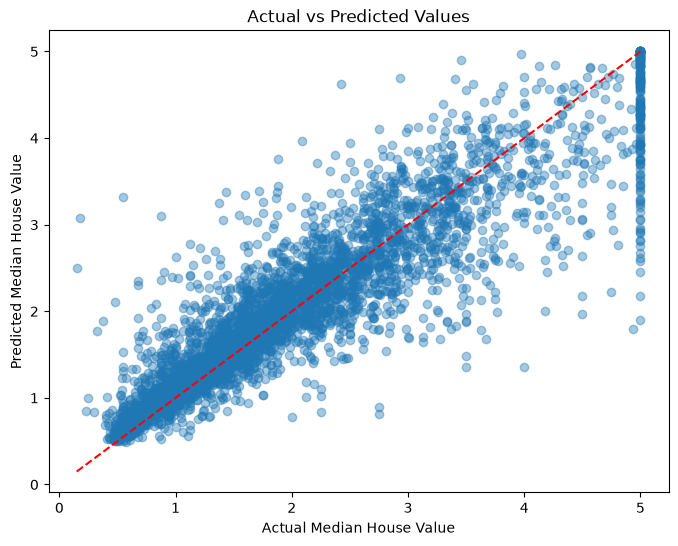

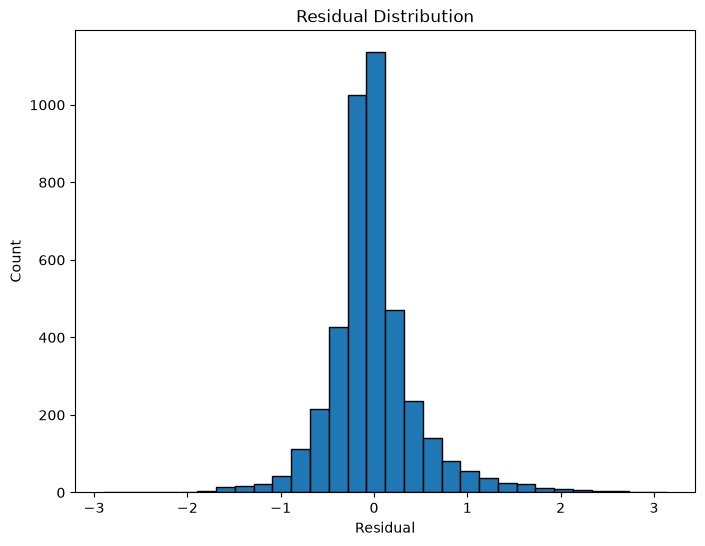

In [24]:
# Code explanation:
# This cell performs part of the ML pipeline.
# Read the inline comments and outputs carefully.

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.title('Actual vs Predicted Values')
plt.show()

residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, edgecolor='k')
plt.title('Residual Distribution')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.show()

## 10. Save the trained model
Save the preprocessor and model for later reuse.

In [25]:
# Code explanation:
# This cell performs part of the ML pipeline.
# Read the inline comments and outputs carefully.

import joblib

joblib.dump(model, 'california_housing_model.joblib')
joblib.dump(preprocessor, 'california_housing_preprocessor.joblib')

['california_housing_preprocessor.joblib']

## 11. Project summary
- Loaded and explored the California Housing dataset.
- Used stratified sampling based on income categories.
- Built a preprocessing pipeline and trained a Random Forest model.
- Evaluated model performance with RMSE, MAE, and R².
- Saved the trained model and preprocessing pipeline.

## Model Testing
This section demonstrates predictions on a few sample inputs after the model has been trained.

In [26]:
# Test the trained model with a few sample values.
import pandas as pd

if 'model' in globals():
    try:
        if 'X_test' in globals():
            samples = X_test.head(5)
            print("Sample input:")
            display(samples)
            print("\nPredictions:")
            print(model.predict(samples))
        else:
            print("X_test not found. Create a DataFrame matching the training features.")
    except Exception as e:
        print("Testing failed:", e)
else:
    print("No variable named 'model' found. Replace 'model' with your trained model variable name if needed.")


Sample input:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
5241,8.2816,29.0,6.715625,1.054167,2184.0,2.275000,34.12,-118.39
17352,5.0099,24.0,7.137809,1.084806,855.0,3.021201,34.89,-120.42
3505,4.3839,36.0,5.283636,0.981818,808.0,2.938182,34.25,-118.45
7777,3.2708,35.0,5.491694,1.079734,1072.0,3.561462,33.91,-118.10
14155,4.3529,38.0,6.154723,1.000000,1495.0,2.434853,32.77,-117.07



Predictions:
[4.0764964 4.0764964 4.0764964 4.0321163 4.0764964]


c:\Users\Puneeth\Desktop\dev-studies\2026 07 13 ML learning\machine-learning-from-scratch\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


## Simplified Linear Regression Training
Removed stratified sampling; use train_test_split(random_state=42).

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
# Separate features and target
X=df.drop('MedHouseVal',axis=1)
y=df['MedHouseVal']
# Split data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
# Train model
model=LinearRegression()
model.fit(X_train,y_train)
pred=model.predict(X_test)
print('R2:',r2_score(y_test,pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test,pred)))
print('MAE:',mean_absolute_error(y_test,pred))
comparison=X_test.head(10).copy()
comparison['Actual']=y_test.head(10).values
comparison['Predicted']=pred[:10]
comparison

R2: 0.5758384503990647
RMSE: 0.745536788375757
MAE: 0.5348517733674298


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,income_cat,Actual,Predicted
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01,2,0.47700,0.737965
3024,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46,2,0.45800,1.703390
15663,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44,3,5.00001,2.775370
20484,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72,4,2.18600,2.833310
9814,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93,3,2.78000,2.592788
13311,4.7147,12.0,5.251483,0.975089,2400.0,2.846975,34.08,-117.61,4,1.58700,2.100887
7113,5.0839,36.0,6.221719,1.095023,670.0,3.031674,33.89,-118.02,4,1.98200,2.710015
7668,3.6908,38.0,4.962825,1.048327,1011.0,3.758364,33.92,-118.08,3,1.57500,2.186620
18246,4.8036,4.0,3.924658,1.035959,1050.0,1.797945,37.39,-122.08,4,3.40000,2.832970
5723,8.1132,45.0,6.879056,1.011799,943.0,2.781711,34.18,-118.23,5,4.46600,3.914896
